# Проект: Статистический анализ данных

Проект направлен на анализ данных популярного сервиса аренды самокатов GoFast. 
Целями проекта являются:
 - Анализ данных о пользователях и поездках
 - Проверка гипотез, которые помогут бизнесу вырасти

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from scipy.stats import binom, norm

#### Шаг 1. Загрузка данных

##### 1.1 Считайте CSV-файлы с данными с помощью библиотеки pandas и сохраните их в датафреймы

Произведём загрузку данных

In [2]:
try:
    df_users = pd.read_csv('./datasets/users_go.csv')
    df_rides = pd.read_csv('./datasets/rides_go.csv')
    df_subs = pd.read_csv('./datasets/subscriptions_go')
except:
    df_users = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
    df_rides = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
    df_subs = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

##### 1.2 Выведите первые строки каждого набора данных. Изучите общую информацию о каждом датафрейме

Рассмотрим датасет с данными о пользователях

In [3]:
df_users.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


Выведем общую информацию о каждом столбце датафрейма с пользователями

In [4]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


Рассмотрим датасет с данными о поездках

In [5]:
df_rides.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


<AxesSubplot:>

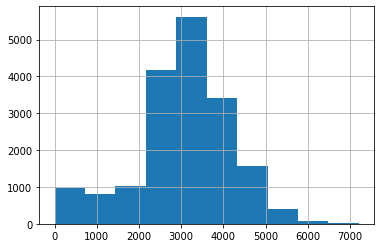

In [6]:
df_rides['distance'].hist()

<AxesSubplot:>

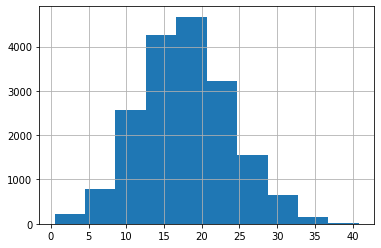

In [7]:
df_rides['duration'].hist()

Рассмотрим датасет с данными о подписках

In [8]:
df_subs.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


**Вывод:** была произведена загрузка данных, получено общее представление о данных

#### Шаг 2. Предобработка данных

Приведём столбец с датой к типу DateTime

In [9]:
df_rides['date'] = pd.to_datetime(df_rides['date'], format="%Y-%m-%d")
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


Создадим столбец с месяцем

In [10]:
df_rides['month'] = df_rides['date'].dt.month
df_rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Рассмотрим датафреймы на дупликаты и пропущенные значения

In [11]:
df_users.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [12]:
df_users.duplicated().sum()

31

In [13]:
df_users = df_users.drop_duplicates()
df_users.duplicated().sum()

0

In [14]:
df_rides.isna().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [15]:
df_rides.duplicated().sum()

0

In [16]:
df_users['city'].value_counts()

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

Пропущенные значения и явные дупликаты устранены. Неявные дупликаты не выявлены

**Вывод:** в результате предобработки данных были выявлены и убраны дубликаты, получен столбец с датой типа DateTime, данные приготовлены к работе

#### Шаг 3. Исследовательский анализ данных

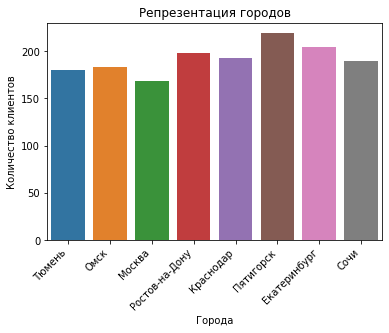

In [17]:
sns.countplot(data=df_users, x='city')
plt.xticks(rotation=45, ha='right')
plt.title('Репрезентация городов')
plt.xlabel('Города')
plt.ylabel('Количество клиентов')
plt.show()

In [18]:
df_users['city'].value_counts(normalize=True)

Пятигорск         0.142764
Екатеринбург      0.132986
Ростов-на-Дону    0.129074
Краснодар         0.125815
Сочи              0.123207
Омск              0.119296
Тюмень            0.117340
Москва            0.109518
Name: city, dtype: float64

Самый представленный город в датафрейме - Пятигорск. Москва представлена меньше всего

<AxesSubplot:title={'center':'Соотношение групп пользователей'}>

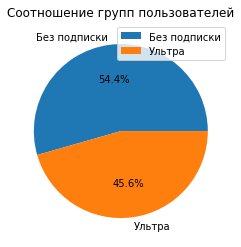

In [19]:
subs_counts = pd.pivot_table(data=df_users, index=['subscription_type'], values=['user_id'], aggfunc='count')
subs_counts.plot.pie(autopct='%1.1f%%', y='user_id', title='Соотношение групп пользователей', ylabel='', labels=['Без подписки', 'Ультра'])

Пользователей без подписки больше чем с подпиской на ~10%

<AxesSubplot:title={'center':'Возраст пользователей'}, xlabel='Возраст', ylabel='Количество'>

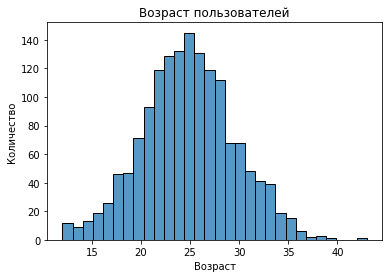

In [20]:
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество')
sns.histplot(data=df_users, x='age')

In [21]:
df_users['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

Средний возраст пользователей в выборкке - 25. Распределение возраста напоминает нормальное

<div style="font-family: Georgia, serif; background: rgba(255, 248, 200, 0.85); color: #4b4100; padding: 16px 22px; margin: 16px 0; border-left: 5px solid #bfa930; border-radius: 14px; box-shadow: 0 8px 14px rgba(0, 0, 0, 0.15); backdrop-filter: blur(2px);">
<b>Комментарий ревьюера v.2</b><br><br>
📝 
Также, рекомендую использовать метод describe() для расчета описательных статистик.
</div>

<AxesSubplot:title={'center':'Дистанция поездок'}, xlabel='Расстояние', ylabel='Количество'>

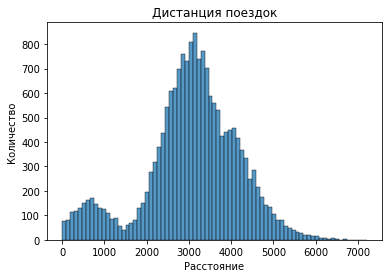

In [22]:
plt.title('Дистанция поездок')
plt.xlabel('Расстояние')
plt.ylabel('Количество')
sns.histplot(data=df_rides, x='distance')

In [23]:
df_rides['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

Средняя дистанция поездок ~3133 метра. При этом можно наблюдать 3 локальных пика на 800, 3200 и 4500 метрах

<AxesSubplot:title={'center':'Длительность поездок'}, xlabel='Длительность', ylabel='Количество'>

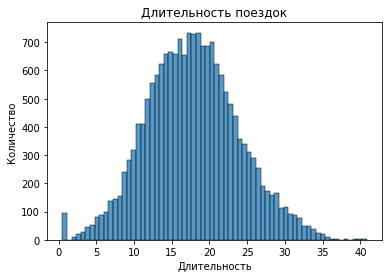

In [24]:
plt.title('Длительность поездок')
plt.xlabel('Длительность')
plt.ylabel('Количество')
sns.histplot(data=df_rides, x='duration')

Мы можем наблюдать большое количество поездок длительностью в ～1 минуту. Это можно объяснить тем что пользователи часто "передумывают" ехать сразу после оформления поездки. Средняя длительность поездок～19 минут. Распределение близко к нормальному

**Вывод:** в результате был проведён анализ и визуализация общей информации о пользователях и поездках

#### Шаг 4. Объединение данных

Объединим датафреймы в 1

Посмотрим размеры исходных датасетов

In [25]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 104.2+ KB


In [26]:
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 705.9 KB


Объединим датасеты

In [27]:
df = df_users.merge(df_rides, on="user_id").merge(df_subs, on="subscription_type")
df.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


Проверяем размерность нового датасета

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   date               18068 non-null  datetime64[ns]
 8   month              18068 non-null  int64         
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


Проверка на дубликаты и пропуски

In [29]:
df.duplicated().sum()

0

In [30]:
df.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Объединение данных прошло успешно, размерности датасетов совпадают, дубликатов и пропусков не выявлено

Выделим отдельно пользователей с и без подписки

In [31]:
df_subbed = df[df['subscription_type'] == 'ultra']
df_subbed['subscription_type'].value_counts()

ultra    6500
Name: subscription_type, dtype: int64

In [32]:
df_unsubbed = df[df['subscription_type'] == 'free']
df_unsubbed['subscription_type'].value_counts()

free    11568
Name: subscription_type, dtype: int64

Рассмотрим как различаются поездки у разных категорий пользователей

<AxesSubplot:title={'center':'Длительность поездок у подписчиков'}, xlabel='Длительность', ylabel='Количество'>

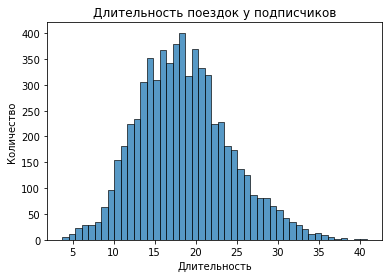

In [33]:
plt.title('Длительность поездок у подписчиков')
plt.xlabel('Длительность')
plt.ylabel('Количество')
sns.histplot(data=df_subbed, x='duration')

In [34]:
df_subbed['duration'].describe()

count    6500.000000
mean       18.541985
std         5.572048
min         3.760353
25%        14.524654
50%        18.178153
75%        21.884129
max        40.823963
Name: duration, dtype: float64

<AxesSubplot:title={'center':'Длительность поездок у обычных пользователей'}, xlabel='Длительность', ylabel='Количество'>

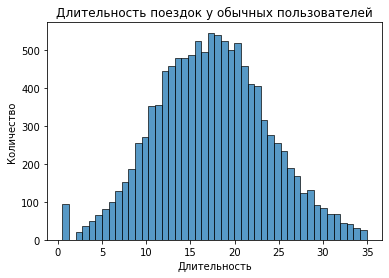

In [35]:
plt.title('Длительность поездок у обычных пользователей')
plt.xlabel('Длительность')
plt.ylabel('Количество')
sns.histplot(data=df_unsubbed, x='duration')

In [36]:
df_unsubbed['duration'].describe()

count    11568.000000
mean        17.390909
std          6.326803
min          0.500000
25%         12.958437
50%         17.326890
75%         21.594071
max         34.948498
Name: duration, dtype: float64

Пользователи без подписки замечены за быстрой отменой поездки (что странно, ведь старты у них платные). Средняя продолжительность поездки не сильно отличается у двух категорий пользователей, однако пользователи c подпиской больше предпочитают долгие поездки. Средняя длительность поездки у подписчиков на ~1.2 минуты дольше чем у пользователей без подписки.

<AxesSubplot:title={'center':'Дистанция поездок у подписчиков'}, xlabel='Дистанция', ylabel='Количество'>

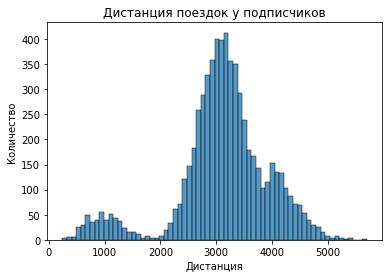

In [37]:
plt.title('Дистанция поездок у подписчиков')
plt.xlabel('Дистанция')
plt.ylabel('Количество')
sns.histplot(data=df_subbed, x='distance')

In [38]:
df_subbed['distance'].describe()

count    6500.000000
mean     3115.445388
std       836.895330
min       244.210438
25%      2785.444017
50%      3148.637229
75%      3560.574425
max      5699.769662
Name: distance, dtype: float64

<AxesSubplot:title={'center':'Дистанция поездок у обычных пользователей'}, xlabel='Дистанция', ylabel='Количество'>

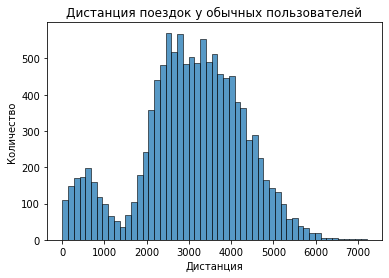

In [39]:
plt.title('Дистанция поездок у обычных пользователей')
plt.xlabel('Дистанция')
plt.ylabel('Количество')
sns.histplot(data=df_unsubbed, x='distance')

In [40]:
df_unsubbed['distance'].describe()

count    11568.000000
mean      3045.495282
std       1246.173806
min          0.855683
25%       2366.562689
50%       3114.648465
75%       3905.697894
max       7211.007745
Name: distance, dtype: float64

Пользователи без подпиской чаще предпочитают дальние поездки. Хотя среднее расстояние поездок у двух категорий отличается лишь на ~70м, 3й квартиль у двух категорий различается на 340м в сторону пользователей без подписки. 

**Вывод:** в результате объединения данных были получен объединённый датафрейм, провизуализирована информация о расстоянии и времени поездок для пользователей обеих категорий. На основе данных видно, что в среднем, пользователи без подписки тратят на поездки меньше времени (на 1.2 минуты), но проезжают дальше (на 70м), следовательно можно сделать вывод что пользователи без подписки ездят с большей скоростью, что может быть опасно, для самих самокатов

#### Шаг 5. Подсчёт выручки

Создадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 4

In [41]:
# На всякий случай делаем глубокую копию, чтобы не потерять изначальные данные после округления
df_ceiled = df.copy()
df_ceiled['duration'] = np.ceil(df_ceiled['duration'])

df_groupped = df_ceiled.groupby(['user_id', 'month', 'subscription_type']).agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    trips_count=('duration', 'count')
).reset_index()
df_groupped.head()

,user_id,month,subscription_type,total_distance,total_duration,trips_count
0,1,1,ultra,7027.511294,42.0,2
1,1,4,ultra,754.159807,7.0,1
2,1,8,ultra,6723.470560,46.0,2
3,1,10,ultra,5809.911100,32.0,2
4,1,11,ultra,7003.499363,56.0,3


Добавим вспомогательные столбцы

In [48]:
monthly_revenue_subdf = df.groupby(['user_id', 'month']).agg(
    total_rides=('start_ride_price', 'count'),
    total_duration=('duration', 'sum'),
    minute_price=('minute_price', 'first'),
    subscription_fee=('subscription_fee', 'first'),
    start_ride_price=('start_ride_price', 'first')
).reset_index()
monthly_revenue_subdf.head()

,user_id,month,total_rides,total_duration,minute_price,subscription_fee,start_ride_price
0,1,1,2,41.416640,6,199,0
1,1,4,1,6.232113,6,199,0
2,1,8,2,44.776802,6,199,0
3,1,10,2,31.578017,6,199,0
4,1,11,3,53.397424,6,199,0


Вычисляем выручку по формуле

In [49]:
df_groupped['monthly_revenue'] = (
    monthly_revenue_subdf['start_ride_price'] * monthly_revenue_subdf['total_rides'] +
    monthly_revenue_subdf['minute_price'] * monthly_revenue_subdf['total_duration'] +
    monthly_revenue_subdf['subscription_fee']
)

df_groupped.head()

,user_id,month,subscription_type,total_distance,total_duration,trips_count,monthly_revenue
0,1,1,ultra,7027.511294,42.0,2,447.499843
1,1,4,ultra,754.159807,7.0,1,236.392681
2,1,8,ultra,6723.470560,46.0,2,467.660815
3,1,10,ultra,5809.911100,32.0,2,388.468102
4,1,11,ultra,7003.499363,56.0,3,519.384541


**Вывод:** был получен датафрейм с помесячной выручкой для каждого пользователя, выручка посчитана

#### Шаг 6. Проверка гипотез

**Для проверки гипотез будем использовать уровень статистической значимости в 5%**

In [44]:
alpha = 0.05

Тратят ли пользователи с подпиской больше времени на поездки? Проверим одностророннюю гипотезу, где H0 - две группы тратят одинаковое время на поездки, H1 - пользователи с подпиской тратят больше времени на поездки

In [45]:
results = st.ttest_ind(df_subbed['duration'], df_unsubbed['duration'], alternative='greater')
if (results.pvalue < alpha):
    print(f"P-value равен {results.pvalue}. " 
          "Отвергаем нулевую гипотезу. Есть основания предполагать что пользователи с оплаченной подпиской " 
          "тратят больше времени на поездки, чем пользователи без подписки")
else:
    print(f"P-value равен {results.pvalue}. " 
          "Принимаем нулевую гипотезу. Нет оснований предполагать что пользователи с оплаченной подпиской " 
          "тратят больше времени на поездки, чем пользователи без подписки")

P-value равен 1.2804098316645618e-34. Отвергаем нулевую гипотезу. Есть основания предполагать что пользователи с оплаченной подпиской тратят больше времени на поездки, чем пользователи без подписки


Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверим одностороннюю гипотезу: нулевая гипотеза - средняя дистанция поездки пользователей с подпиской равняется 3130м, альтернативная гипотеза - средняя дистанция поездки пользователей с подпиской больше 3130м

In [46]:
results = st.ttest_1samp(df_subbed['distance'], 3130, alternative='greater')
if(results.pvalue < alpha):
    print(f"P-value равен {results.pvalue}. " 
          "Отвергаем нулевую гипотезу. Есть основания предполагать что пользователи " 
          "с подпиской в среднем проезжают больше 3130 метров за поездку")
else:
    print(f"P-value равен {results.pvalue}. " 
          "Принимаем нулевую гипотезу. Нет оснований предполагать что пользователи " 
          "с подпиской в среднем проезжают больше 3130 метров за поездку. "
          "Их средняя дистанция поездки - 3130 метров")

P-value равен 0.9195368847849785. Принимаем нулевую гипотезу. Нет оснований предполагать что пользователи с подпиской в среднем проезжают больше 3130 метров за поездку. Их средняя дистанция поездки - 3130 метров


Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Нулевая гипотеза гласит: помесячная выручка от пользователей с подпиской по месяцам равна выручке от пользователей без подписки. Альтернативная гипотеза - помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

In [47]:
results = st.ttest_ind(df_groupped[df_groupped['subscription_type'] == 'ultra']['monthly_revenue'], 
             df_groupped[df_groupped['subscription_type'] == 'free']['monthly_revenue'], 
             alternative='greater')
if (results.pvalue < alpha):
    print(f"P-value равен {results.pvalue}. " 
          "Отвергаем нулевую гипотезу. Есть основания полагать что пользователи с подпиской приносят " 
          "сервису в среднем больше доходов чем пользователи без подписки")
else:
    print(f"P-value равен {results.pvalue}. " 
          "Принимаем нулевую гипотезу. Нет оснований полагать что пользователи с подпиской приносят " 
          "сервису в среднем больше доходов чем пользователи без подписки "
          "Выручка с двух групп в среднем одинакова")

P-value равен 2.899911210580282e-37. Отвергаем нулевую гипотезу. Есть основания полагать что пользователи с подпиской приносят сервису в среднем больше доходов чем пользователи без подписки


Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

В задаче идёт речь о равенстве средних для зависимых (парных) выборок. Нулевая гипотеза звучит: выборочное среднее количества запросов пользователей до обновления равно выборочному среднему количества запросов пользователей до него. Альтернативная гипотеза - выборочное среднее количества запросов пользователей до обновления **меньше**  выборочного среднего количества запросов пользователей до него. Используем функцию **ttest_rel**, с параметром `alternative='less'`

**Вывод:** в результате были проверены интересующие бизнес гипотезы

**Общий вывод:** в результате выполнения проекта были изучены данные о пользователях и их поездках сервиса шейринга самокатов. Была проведена предобработка данных в результате которой данные были подготовлены к работе. Был проведён исследовательский анализ данных, проведён подсчёт выручки сервиса и проверены интересующие заказчика гипотезы

В ходе выполнения анализа были выявлены следующие особенности:

 - Самый представленный город в данных - Пятигорск, меньше всего представлена Москва
 - Доля пользователей без подписки - 54.4%, доля подписчиков - 45.6%
 - Средний возраст пользователей - 25 лет. Самый молодой пользователь имеет возраст 12 лет, самый возрастной - 43 года
 - Средняя дистанция поездок - 3133 метра. Также наблюдается тенденция того что пользователи без подписки часто "передумывают" ехать сразу после оформления поездки.
 - Пользователи без подпиской чаще предпочитают дальние поездки. Хотя среднее расстояние поездок у двух категорий отличается лишь на ~70м, 3й квартиль у двух категорий различается на 340м в сторону пользователей без подписки
 - Есть основания предполагать что пользователи с оплаченной подпиской тратят больше времени на поездки, чем пользователи без подписки
 - Нет оснований предполагать что пользователи с подпиской в среднем проезжают больше 3130 метров за поездку. Их средняя дистанция поездки - 3130 метров
 - Есть основания полагать что пользователи с подпиской приносят сервису в среднем больше доходов чем пользователи без подписки
 